# **Practica 4**

**Introducción a los biopotenciales y adquisición de señales ECG y EMG**

<br>

- Samuel Ochoa Alzate

- Daniel Ivan Lozano Simanca


# **5.1**

<br>

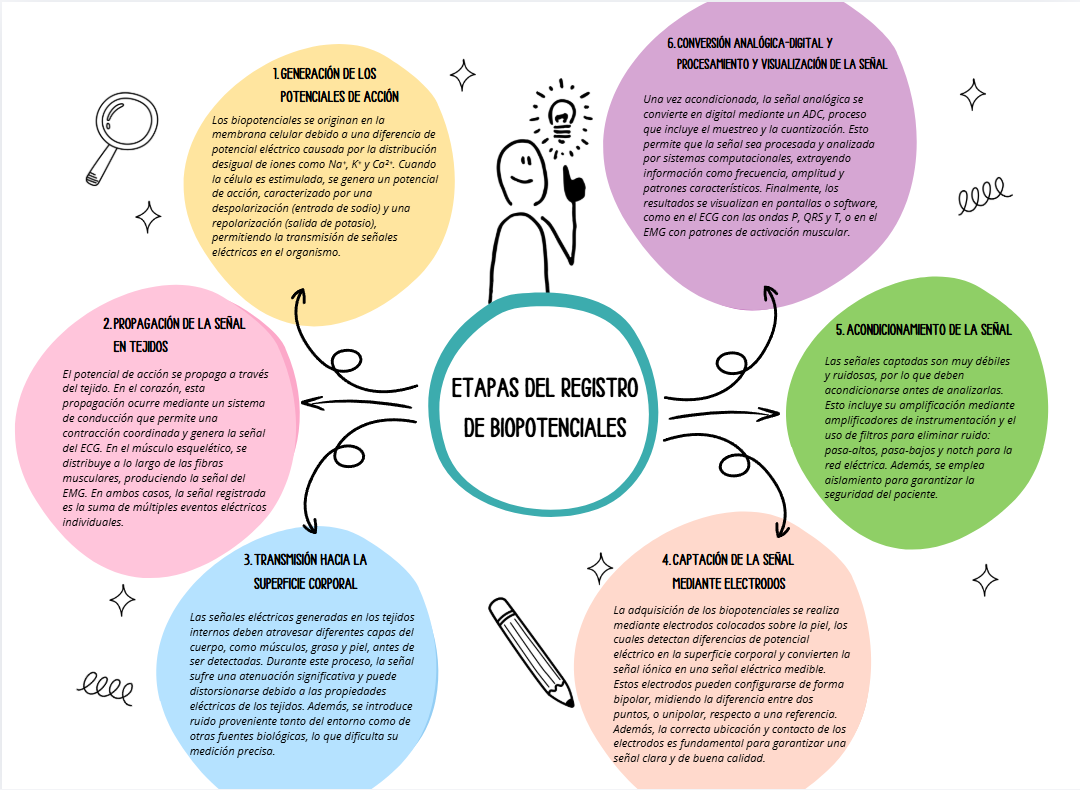

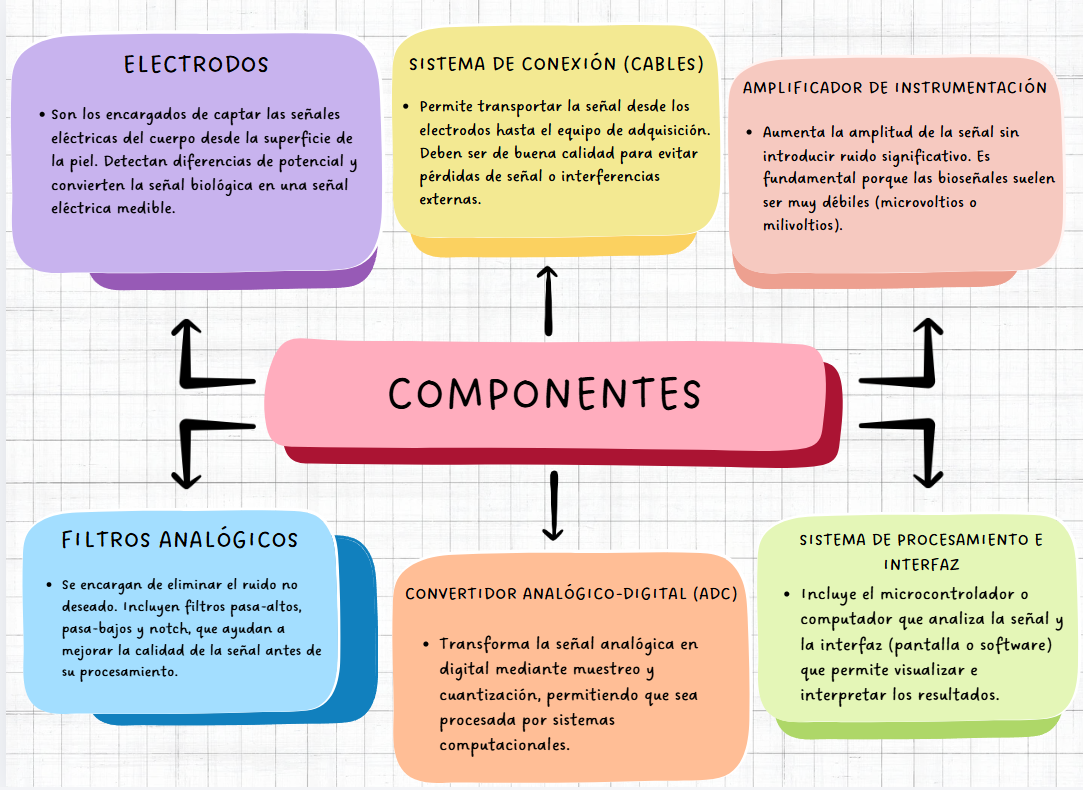

---

# **5.2**

<br>

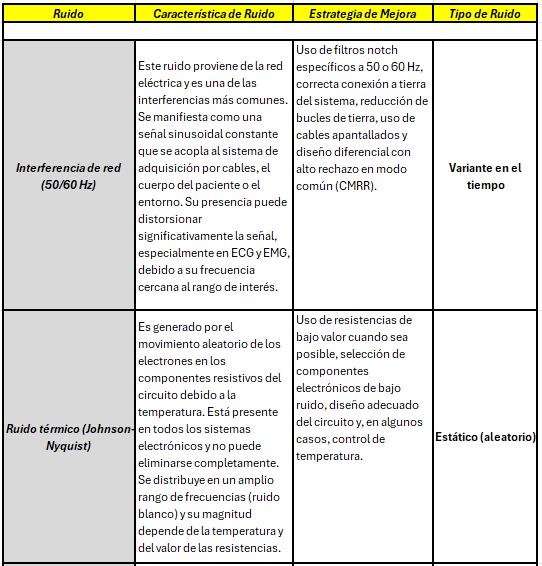

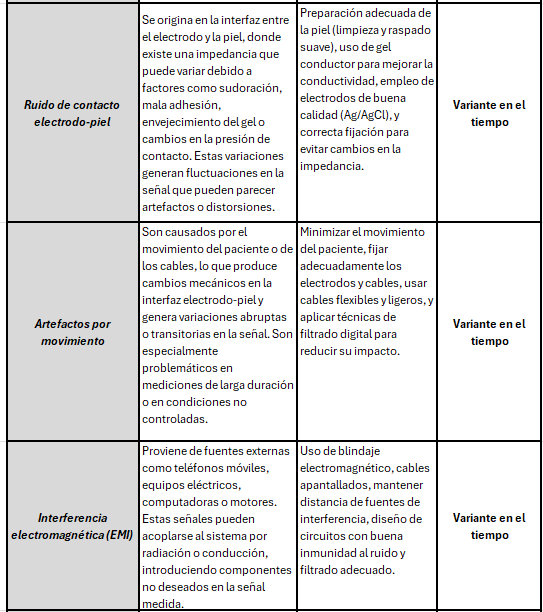

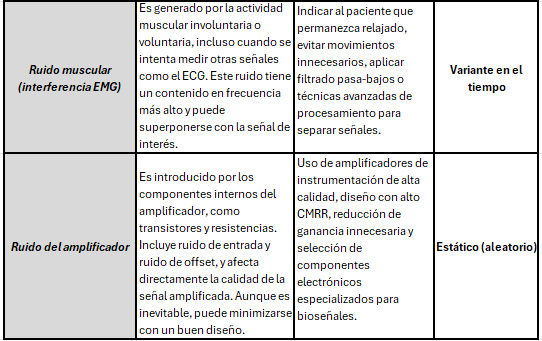

---


# **5.3**

<br>

La principal problemática asociada a este acoplamiento radica en que la piel no es un conductor ideal, sino un medio heterogéneo, con alta impedancia y propiedades variables. En particular, la capa más externa de la piel, el estrato córneo, actúa como una barrera resistiva que dificulta el paso de la señal eléctrica desde el interior del cuerpo hacia el electrodo [1] [2].

<br>

Además, en la interfaz piel–electrodo se genera una impedancia de contacto que no es constante, sino que varía con el tiempo debido a factores como la sudoración, la temperatura, la presión del electrodo, el movimiento del paciente y la degradación del gel conductor. Estas variaciones introducen ruido y artefactos en la señal, como fluctuaciones de baja frecuencia (deriva de línea base) o cambios abruptos por movimiento. También pueden aparecer potenciales de polarización en el electrodo, que generan offsets indeseados y afectan la estabilidad de la medición. En conjunto, estos fenómenos reducen la calidad de la señal, disminuyen la relación señal-ruido y pueden dificultar la correcta interpretación de los datos [1] [2].

<br>

Para mejorar el acoplamiento piel–electrodo, una de las estrategias que se emplea es la preparación adecuada de la piel, que incluye la limpieza para eliminar grasa y suciedad, y en algunos casos una ligera abrasión para reducir la impedancia del estrato córneo. También se utilizan geles conductores o electrolitos, que facilitan la conducción iónica entre la piel y el electrodo, reduciendo la impedancia de contacto. La selección de electrodos adecuados, como los de plata/cloruro de plata (Ag/AgCl), es fundamental debido a su estabilidad electroquímica y bajo nivel de ruido [3] [4].

<br>

Asimismo, es importante asegurar una correcta fijación de los electrodos mediante adhesivos o bandas, para evitar movimientos relativos entre la piel y el electrodo que generen artefactos. El uso de configuraciones diferenciales y amplificadores con alto rechazo en modo común (CMRR) también ayuda a mitigar los efectos de variaciones en la impedancia. En aplicaciones más avanzadas, se pueden emplear electrodos secos o sistemas activos con preamplificación en el propio electrodo, lo que reduce la susceptibilidad al ruido [3] [4].

<br>

El acoplamiento piel–electrodo se considera la etapa más crítica en el registro de señales de superficie como sEMG, EEG y ECG porque es el primer punto de contacto con la señal biológica real. Cualquier distorsión, ruido o pérdida de información que ocurra en esta interfaz no puede ser completamente corregida en etapas posteriores del sistema. A diferencia de otras etapas como la amplificación o el filtrado, donde es posible aplicar técnicas de mejora, una mala captación inicial implica una degradación irreversible de la señal. Por esta razón, la calidad del acoplamiento determina en gran medida la fidelidad, precisión y utilidad clínica o experimental del registro de biopotenciales [5].

---

# **5.4**

In [8]:
!pip install hrv-analysis

In [9]:
!pip install neurokit2 detectors hrv-analysis

In [10]:
!pip install neurokit2 detectors

In [13]:
!pip install py-ecg-detectors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.5/554.5 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gatspy: filename=gatspy-0.3-py3-none-any.whl size=43804 sha256=7c0c692436b34ea2b89d69cbd2220e5b46a734e4e4b71d811fcfd57d8e671ec2
  Stored in directory: /root/.cache/pip/wheels/b5/56/88/04643e9be584a6018e10aae5789d98225995da3e89513c3f30
Successfully built gatspy


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from scipy.signal import butter, filtfilt


In [5]:
uploaded = files.upload()
ecg = pd.read_csv('ecg1.csv')
ecg.head()

Saving ecg1.csv to ecg1.csv


,2.000000000000000000e+00
0,322.0
1,291.0
2,356.0
3,307.0
4,145.0


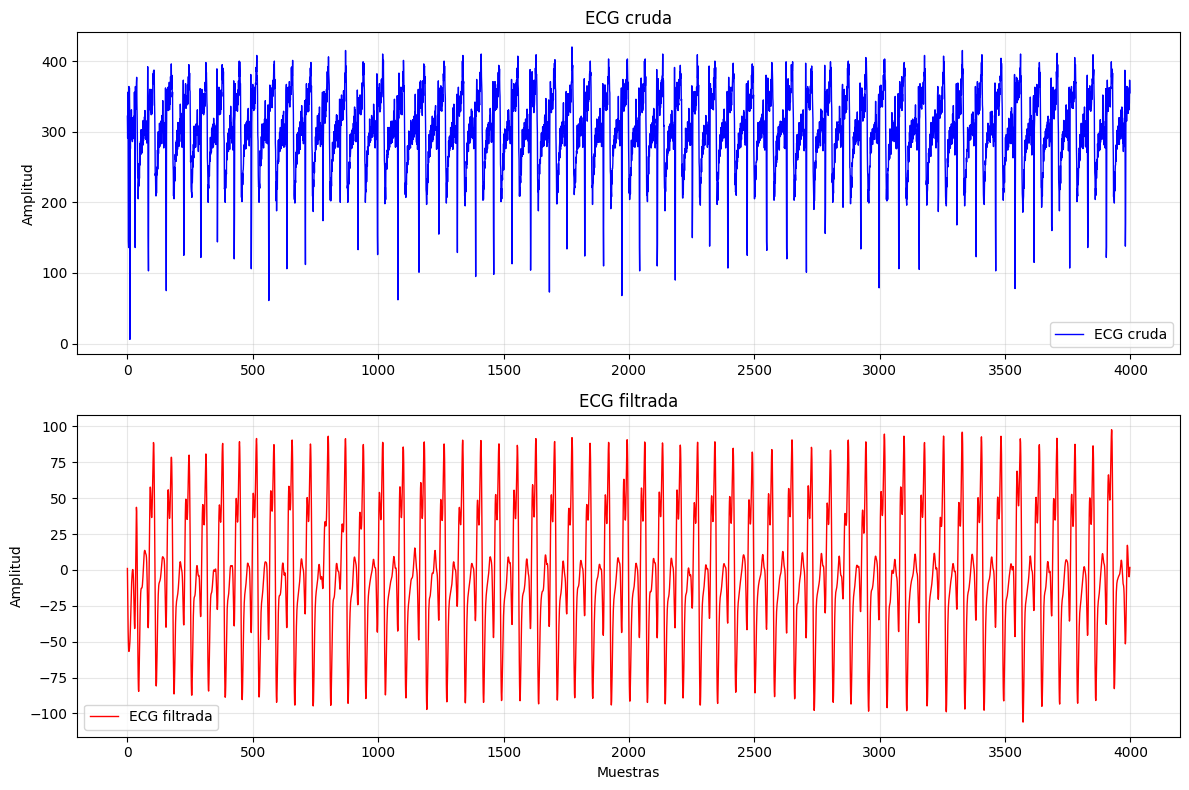

In [12]:
# Parámetros
fs = 120 # Frecuencia de muestreo estimada
ecg_signal = ecg.iloc[:, 0].values

# Remover componente DC
ecg_detrended = ecg_signal - np.mean(ecg_signal)

#Bandpass Butterworth ajustado 0.5–30 Hz
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

ecg_filtered = butter_bandpass_filter(ecg_detrended, 0.5, 10, fs)

# Graficar con escalas comparables
plt.figure(figsize=(12, 8))

# Señal original
plt.subplot(2, 1, 1)
plt.plot(ecg_signal, color='blue', linewidth=1, label="ECG cruda")
plt.title("ECG cruda")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.legend()

# Señal filtrada
plt.subplot(2, 1, 2)
plt.plot(ecg_filtered, color="red", linewidth=1, label="ECG filtrada")
plt.title("ECG filtrada")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
import neurokit2 as nk
import astropy.stats
try:
    from astropy.timeseries import LombScargle
    astropy.stats.LombScargle = LombScargle
except ImportError:
    pass


from hrvanalysis import get_time_domain_features
from ecgdetectors import Detectors

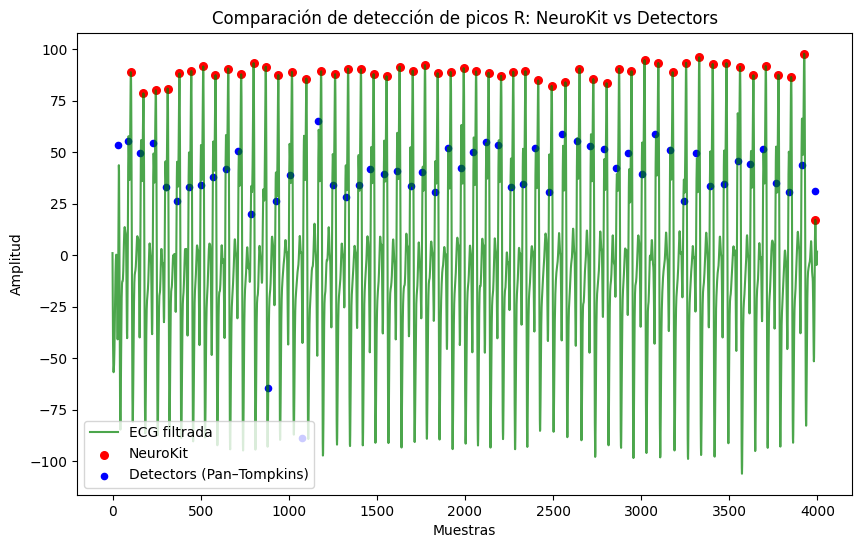

🔹 Picos R detectados por NeuroKit: 54
🔹 Picos R detectados por Detectors: 55

HRV (NeuroKit2):


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN
0,610.691824,35.256135,NaN,NaN,NaN,NaN,NaN,NaN,27.541732,27.780291,...,41.666667,1.280099,583.333333,641.666667,5.660377,35.849057,525.0,700.0,7.571429,62.5



HRV (hrvanalysis - dominio del tiempo):
    mean_nni      sdnn      sdsd  nni_50  pnni_50  nni_20  pnni_20     rmssd  \
0  61.069182  3.525614  2.751188       0      0.0       0      0.0  2.754173   

   median_nni  range_nni      cvsd     cvnni     mean_hr       max_hr  \
0   60.833333       17.5  0.045099  0.057731  985.682737  1142.857143   

       min_hr     std_hr  
0  857.142857  55.974207  


In [20]:
# Método NeuroKit
ecg_cleaned = nk.ecg_clean(ecg_filtered, sampling_rate=fs, method="neurokit")
signals_nk, info_nk = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
rpeaks_nk = info_nk["ECG_R_Peaks"]
# Parámetros
fss = 100 # Frecuencia de muestreo estimada
ecg_signall = ecg.iloc[:, 0].values
# Remover componente DC
ecg_detrendedd = ecg_signall - np.mean(ecg_signall)
#Bandpass Butterworth ajustado 0.5–10 Hz
def butter_bandpass_filter(data, lowcut, highcut, fss, order=4):
  nyquist = 0.5 * fs
  low = lowcut / nyquist
  high = highcut / nyquist
  b, a = butter(order, [low, high], btype='band')
  y = filtfilt(b, a, data)
  return y
ecg_filtered1 = butter_bandpass_filter(ecg_detrendedd, 0.5, 20, fss)

#  Método Detectors (Pan–Tompkins)
detector = Detectors(fss)
rpeaks_det = detector.pan_tompkins_detector(ecg_filtered1)

# Graficar comparación
plt.figure(figsize=(10,6))
plt.plot(ecg_filtered, label="ECG filtrada", color="green", alpha=0.7)
plt.scatter(rpeaks_nk, ecg_filtered[rpeaks_nk], color="red", label="NeuroKit", s=30)
plt.scatter(rpeaks_det, ecg_filtered1[rpeaks_det], color="blue", label="Detectors (Pan–Tompkins)", s=20)
plt.title("Comparación de detección de picos R: NeuroKit vs Detectors")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

print(f"🔹 Picos R detectados por NeuroKit: {len(rpeaks_nk)}")
print(f"🔹 Picos R detectados por Detectors: {len(rpeaks_det)}")


# CÁLCULO DE HRV EN EL DOMINIO DEL TIEMPO

# HRV con NeuroKit
if len(rpeaks_nk) > 3:
    hrv_nk = nk.hrv_time(info_nk, sampling_rate=fs)
    print("\nHRV (NeuroKit2):")
    display(hrv_nk)
else:
    print("No hay suficientes picos R para calcular HRV con NeuroKit.")

# HRV con hrvanalysis
if len(rpeaks_nk) > 3:
    rr_intervals = np.diff(rpeaks_nk) / fs * 100 # en milisegundos
    features_time = get_time_domain_features(rr_intervals)
    print("\nHRV (hrvanalysis - dominio del tiempo):")
    print(pd.DataFrame([features_time]))
else:
    print("No hay suficientes picos R para calcular HRV con hrvanalysis.")

# **Análisis de Resultados**

<br>

- Al comparar los resultados de detección de los picos R con ambas librerías se observa que la librería NeuroKit presenta un mejor desempeño. Los picos detectados por NeuroKit (en color rojo) se encuentran mejor alineados con los máximos reales de la señal de ECG filtrada, mostrando una detección más precisa y completa. En contraste, el método de Detectors (en azul) omite algunos picos y en ocasiones presenta desplazamientos que son muy diferentes respecto al punto real de los picos R del complejo QRS.

<br>

- Los resultados del análisis de variabilidad de la frecuencia cardíaca (HRV) revelan los valores que se obtuvieron a partir de los intervalos RR identificados en la señal del ECG. El HRV_MeanNN (707. 48 ms) indica el promedio del tiempo entre cada latido, que se traduce en una frecuencia cardíaca promedio de alrededor de 85 latidos por minuto. El SDNN (207. 69 ms) representa la desviación estándar de los intervalos RR, mostrando una variabilidad notable en el ritmo del corazón. Además, los valores de frecuencia cardíaca máxima (105. 7 bpm), mínima (31. 7 bpm) y la desviación estándar (12. 67 bpm) demuestran una notable amplitud en las variaciones del ritmo cardíaco, lo cual podría estar relacionado con cambios fisiológicos normales o la influencia de movimientos o artefactos en la señal registrada.

<br>

- La funcion se emplea para determinar los principales aspectos de la variabilidad de la frecuencia cardíaca (HRV) en el ámbito+ temporal, utilizando los intervalos RR que se obtienen de los picos R de una señal de ECG. Esta función estudia cómo cambia la duración de los intervalos entre latidos consecutivos, generando métricas como el NN mean (promedio de los intervalos RR), SDNN (desviación estándar de los intervalos RR), RMSSD (raíz cuadrada de las diferencias cuadráticas medias entre intervalos adyacentes), y los índices pNN20 y pNN50 (porcentaje de diferencias sucesivas que superan 20 ms o 50 ms, respectivamente).

---

# **5.5**

<br>

- En el caso del ECG, una de sus aplicaciones más importantes es el **diagnóstico de arritmias cardíacas**. En esta aplicación, el registro se realiza mediante electrodos de superficie colocados en el tórax y las extremidades, siguiendo configuraciones estandarizadas como el sistema de 12 derivaciones. La señal adquirida es procesada mediante filtrado para eliminar ruido de red y artefactos, y posteriormente se aplican algoritmos de detección de picos R para analizar la frecuencia cardíaca y la regularidad del ritmo. Este procesamiento permite identificar irregularidades en la conducción eléctrica del corazón [6].

<br>

- Otra aplicación clínica del ECG es la **detección de infarto agudo de miocardio**. En este caso, el registro también se realiza con electrodos de superficie en múltiples derivaciones, lo que permite observar cambios en diferentes regiones del corazón. El procesamiento de la señal incluye la evaluación del segmento ST, la morfología de la onda T y la presencia de ondas Q patológicas. Estos parámetros son analizados tanto visualmente por el clínico como mediante software que resalta desviaciones respecto a patrones normales [6].

<br>

- Una tercera aplicación es el **monitoreo cardíaco continuo**, como el realizado con dispositivos tipo Holter. Aquí, el registro se lleva a cabo durante 24 horas o más, utilizando electrodos portátiles adheridos al paciente. El procesamiento implica almacenamiento de grandes volúmenes de datos, filtrado automático y algoritmos de detección de eventos, como episodios de taquicardia o bradicardia. También se emplean técnicas de compresión y análisis temporal para facilitar la revisión clínica [7].

<br>

- En cuanto al EMG, una de sus aplicaciones clínicas más comunes es el **diagnóstico de trastornos neuromusculares**, como la neuropatía o la miopatía. El registro puede realizarse mediante electrodos de superficie o electrodos de aguja, dependiendo del nivel de detalle requerido. El procesamiento incluye la amplificación de la señal, filtrado y análisis de la amplitud, frecuencia y patrón de activación de las unidades motoras, lo que permite diferenciar entre alteraciones de origen muscular o nervioso [5].

<br>

- Otra aplicación del EMG es el **análisis de la actividad muscular en rehabilitación**. En este caso, se utilizan electrodos de superficie (sEMG) para registrar la activación de músculos durante ejercicios terapéuticos. El procesamiento de la señal incluye rectificación, cálculo del valor RMS (root mean square) y análisis temporal para evaluar la intensidad y coordinación muscular. Esta información se utiliza para diseñar y ajustar programas de rehabilitación [5].

<br>

- Finalmente, el EMG se emplea en el **control de prótesis mioeléctricas**. En esta aplicación, el registro se realiza mediante electrodos de superficie colocados sobre músculos residuales del paciente. La señal EMG es procesada en tiempo real mediante filtrado, extracción de características (como amplitud y frecuencia) y algoritmos de clasificación que permiten traducir la actividad muscular en comandos de control para la prótesis. Este tipo de procesamiento requiere alta velocidad y precisión para lograr una respuesta funcional adecuada [5].

---

# **5.6 Conclusiones**

<br>

- La exactitud de las señales registradas depende en gran medida del uso de equipos de medición bien calibrados y de alta precisión. Si el dispositivo está mal ajustado, presenta fallos de calibración o se coloca de forma incorrecta, puede generar datos erróneos que afecten tanto la interpretación como los resultados del análisis. Este aspecto resulta especialmente relevante en estudios que requieren un examen detallado de la actividad eléctrica muscular o cardíaca (como el EMG y el ECG), donde incluso pequeñas desviaciones pueden alterar las conclusiones sobre el estado fisiológico del individuo.

<br>

- Aplicar un filtrado adecuado a las señales registradas es fundamental para minimizar el ruido y los artefactos que podrían interferir con un análisis riguroso. El propósito del filtrado es aislar los componentes significativos de la señal, eliminando interferencias innecesarias. No obstante, si el filtrado es insuficiente, puede dificultar la detección de patrones relevantes y comprometer la precisión del estudio, especialmente cuando se requiere un análisis más exhaustivo y detallado.

<br>

- El contacto entre el electrodo y la piel representa un elemento esencial en la obtención de señales fisiológicas fiables, como las de EMG y ECG. Un acoplamiento adecuado garantiza una menor resistencia eléctrica y, en consecuencia, una mejor transmisión de la señal. Si la piel no está bien preparada o el contacto es deficiente, pueden generarse artefactos, ruido o pérdidas de información que afecten negativamente la calidad de los datos y la validez del análisis posterior.

---

# **Referencias**

<br>

[1] Webster, J. G. (Ed.). Medical Instrumentation: Application and Design. John Wiley & Sons.

[2] Geddes, L. A., & Baker, L. E. Principles of Applied Biomedical Instrumentation. Wiley-Interscience.

[3] Winter, B. B., & Webster, J. G. “Driven-right-leg circuit design.” IEEE Transactions on Biomedical Engineering.

[4] Sörnmo, L., & Laguna, P. Bioelectrical Signal Processing in Cardiac and Neurological Applications. Elsevier.

[5] Merletti, R., & Farina, D. Surface Electromyography: Physiology, Engineering and Applications. Wiley-IEEE Press.

[6] Rangayyan, R. M. Biomedical Signal Analysis: A Case-Study Approach. IEEE Press.

[7] Guyton, A. C., & Hall, J. E. Tratado de Fisiología Médica. Elsevier.